# DESC ELAsTiCC2 — 05 : Construction des échantillons train/test pour la classification

Ce notebook relit les fichiers parquet produits par
`03_elasticc2_fit_bazin_extract_features.ipynb` (un fichier par type de supernova,
contenant les features Bazin par bande + redshift + flag qualité), les concatène,
filtre les bons fits, construit le label de classification, et effectue un split
train/test **stratifié sur (label, bin de redshift)** afin d'éviter tout biais de
distribution en z entre les deux échantillons.

Sortie : deux fichiers parquet, `train_set.parquet` et `test_set.parquet`, contenant
les features + label + redshift + identifiants, prêts pour l'entraînement d'un
classifieur (ex. Random Forest).

- author : Sylvie Dagoret-Campagne
- creation date : 2026-06-20
- input : fichiers `features/bazin_features_<obj_class>.parquet` produits par `03_elasticc2_fit_bazin_extract_features.ipynb`

## 0 · Imports

In [1]:
%matplotlib inline

import sys
import os
import pathlib
import logging
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

_logger = logging.getLogger("main")
if not _logger.hasHandlers():
    _logout = logging.StreamHandler(sys.stderr)
    _logger.addHandler(_logout)
    _logout.setFormatter(logging.Formatter(
        '[%(asctime)s - %(levelname)s] - %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
_logger.setLevel(logging.INFO)
_logger.info("Imports done.")

[2026-06-20 21:21:15 - INFO] - Imports done.


## 1 · Paramètres

- `FEATURES_DIR` : dossier contenant les fichiers parquet produits par le notebook 03.
- `OBJ_CLASS_LIST` : classes à inclure (doit correspondre aux fichiers présents dans `FEATURES_DIR`).
- `TARGET_MODE` : `'binary'` (SNIa vs non-Ia) ou `'multiclass'` (une classe par `obj_class`).
- `REQUIRE_GOOD_FIT` : si `True`, ne garde que les lignes `is_good_fit == True`.
- `TEST_SIZE` : fraction réservée au test.
- `MAX_Z_BINS` : nombre de bins de redshift visé pour la stratification (réduit automatiquement
  en cas d'effectifs insuffisants — voir Section 3).
- `RANDOM_SEED` : graine pour la reproductibilité du split.
- `OUTPUT_DIR` : dossier où sont écrits `train_set.parquet` / `test_set.parquet`.

In [2]:
# ── Paramètres principaux ────────────────────────────────────────────────────

FEATURES_DIR = pathlib.Path(os.getcwd()) / "features"

OBJ_CLASS_LIST = [
    'SNIa-SALT3',
    'SNIb-Templates',
    'SNIc-Templates',
    'SNII-Templates',
]

TARGET_MODE = 'binary'    # 'binary' (SNIa vs non-Ia) ou 'multiclass'

REQUIRE_GOOD_FIT = True   # ne garder que is_good_fit == True
TEST_SIZE        = 0.2
MAX_Z_BINS        = 5     # nombre de bins de redshift visé pour la stratification
RANDOM_SEED       = 42

OUTPUT_DIR = pathlib.Path(os.getcwd()) / "train_test_sets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"FEATURES_DIR = {FEATURES_DIR}")
print(f"TARGET_MODE  = {TARGET_MODE}")
print(f"OUTPUT_DIR   = {OUTPUT_DIR}")

FEATURES_DIR = /Users/dagoret/Desktop/transcientslightcurves/notebooks/03_fitbazinfunc/features
TARGET_MODE  = binary
OUTPUT_DIR   = /Users/dagoret/Desktop/transcientslightcurves/notebooks/03_fitbazinfunc/train_test_sets


## 2 · Chargement et concaténation des fichiers de features

In [3]:
def load_all_features(features_dir, obj_class_list):
    """
    Charge un parquet par classe (bazin_features_<obj_class>.parquet) et les
    concatène en un seul DataFrame. Lève une erreur explicite si un fichier
    attendu est manquant, mais continue avec les autres (warning).
    """
    dfs = []
    for obj_class in obj_class_list:
        fpath = features_dir / f"bazin_features_{obj_class}.parquet"
        if not fpath.is_file():
            _logger.warning(f"Fichier manquant pour {obj_class} : {fpath} — classe ignorée.")
            continue
        df = pd.read_parquet(fpath)
        _logger.info(f"[{obj_class}] {len(df)} lignes chargées depuis {fpath.name}")
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError(
            f"Aucun fichier de features trouvé dans {features_dir}. "
            f"Avez-vous exécuté 03_elasticc2_fit_bazin_extract_features.ipynb ?"
        )

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all


df_all = load_all_features(FEATURES_DIR, OBJ_CLASS_LIST)
print(f"\nTotal : {len(df_all)} objets chargés, {df_all['obj_class'].nunique()} classes.")
print(df_all.groupby('obj_class').size().rename('n_objects'))

[2026-06-20 21:21:16 - INFO] - [SNIa-SALT3] 1295 lignes chargées depuis bazin_features_SNIa-SALT3.parquet
[2026-06-20 21:21:16 - INFO] - [SNIb-Templates] 204 lignes chargées depuis bazin_features_SNIb-Templates.parquet
[2026-06-20 21:21:16 - INFO] - [SNIc-Templates] 102 lignes chargées depuis bazin_features_SNIc-Templates.parquet
[2026-06-20 21:21:16 - INFO] - [SNII-Templates] 486 lignes chargées depuis bazin_features_SNII-Templates.parquet



Total : 2087 objets chargés, 4 classes.
obj_class
SNII-Templates     486
SNIa-SALT3        1295
SNIb-Templates     204
SNIc-Templates     102
Name: n_objects, dtype: int64


## 3 · Filtrage qualité, construction du label, et split stratifié train/test

### Stratégie de stratification

On stratifie sur la combinaison **(label, bin de redshift)** pour que train et test aient
des distributions de redshift comparables **pour chaque classe**. Avec des échantillons
de petite taille (ex. SNIb/SNIc), certains combos `(label, z_bin)` peuvent avoir moins de
2 membres, ce qui fait échouer `train_test_split(..., stratify=...)`.

`safe_stratified_split` gère cela par une stratégie de repli en cascade :
1. essaie `MAX_Z_BINS` bins de redshift (quantiles) ;
2. si un combo a moins de 2 membres, réduit progressivement le nombre de bins ;
3. en dernier recours, stratifie uniquement sur `label` (sans tenir compte du redshift).

In [4]:
def build_label(df, target_mode):
    """
    Construit la colonne `label` à partir de `obj_class`.
      - 'binary'     : 1 si SNIa-SALT3, 0 sinon (Ib/Ic/II regroupés).
      - 'multiclass' : une valeur de label par obj_class (catégorielle).
    """
    df = df.copy()
    if target_mode == 'binary':
        df['label'] = (df['obj_class'] == 'SNIa-SALT3').astype(int)
        df['label_name'] = df['label'].map({1: 'SNIa', 0: 'non-Ia'})
    elif target_mode == 'multiclass':
        df['label'] = df['obj_class']
        df['label_name'] = df['obj_class']
    else:
        raise ValueError(f"TARGET_MODE inconnu : {target_mode!r} (attendu 'binary' ou 'multiclass')")
    return df

In [5]:
def safe_stratified_split(df, label_col, z_col, test_size=0.2, random_state=42, max_z_bins=5):
    """
    Split train/test stratifié sur (label_col, z_bin), avec repli automatique
    en cas d'effectifs insuffisants pour la stratification.

    Retourne (train_df, test_df, n_bins_used). n_bins_used == 0 signifie que
    le repli total (stratification par label seul, sans tenir compte du
    redshift) a été utilisé.
    """
    df = df.copy()

    for n_bins in range(max_z_bins, 1, -1):
        try:
            z_bin = pd.qcut(df[z_col], q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            continue  # pas assez de valeurs distinctes pour ce nombre de bins

        strat_key = df[label_col].astype(str) + '_' + z_bin.astype(str)
        counts = strat_key.value_counts()

        if (counts >= 2).all():
            df['z_bin'] = z_bin
            train_df, test_df = train_test_split(
                df, test_size=test_size, random_state=random_state, stratify=strat_key
            )
            return train_df, test_df, n_bins

    # ── Repli : stratification par label seul ────────────────────────────
    _logger.warning(
        "Stratification (label, z_bin) impossible (effectifs trop faibles) — "
        "repli sur stratification par label seul, sans contrôle de la distribution en z."
    )
    n_bins_fallback = min(max_z_bins, df[z_col].nunique())
    df['z_bin'] = pd.qcut(df[z_col], q=n_bins_fallback, labels=False, duplicates='drop')
    train_df, test_df = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df[label_col]
    )
    return train_df, test_df, 0

In [6]:
# ── Filtrage qualité ──────────────────────────────────────────────────────
if REQUIRE_GOOD_FIT:
    n_before = len(df_all)
    df_clean = df_all[df_all['is_good_fit'] == True].copy()
    print(f"Filtrage is_good_fit==True : {len(df_clean)}/{n_before} lignes conservées.")
else:
    df_clean = df_all[df_all['fit_success'] == True].copy()
    print(f"Filtrage fit_success==True (is_good_fit non appliqué) : {len(df_clean)}/{len(df_all)} lignes conservées.")

print("\nRépartition par classe après filtrage :")
print(df_clean.groupby('obj_class').size().rename('n_objects'))

if df_clean['redshift'].isna().any():
    n_nan_z = df_clean['redshift'].isna().sum()
    _logger.warning(f"{n_nan_z} objets sans redshift valide — exclus du split.")
    df_clean = df_clean[df_clean['redshift'].notna()].copy()

Filtrage is_good_fit==True : 588/2087 lignes conservées.

Répartition par classe après filtrage :
obj_class
SNII-Templates    125
SNIa-SALT3        386
SNIb-Templates     53
SNIc-Templates     24
Name: n_objects, dtype: int64


In [7]:
# ── Construction du label ────────────────────────────────────────────────
df_labeled = build_label(df_clean, TARGET_MODE)

print("Répartition du label :")
print(df_labeled.groupby(['label_name', 'obj_class']).size().rename('n_objects'))

Répartition du label :
label_name  obj_class     
SNIa        SNIa-SALT3        386
non-Ia      SNII-Templates    125
            SNIb-Templates     53
            SNIc-Templates     24
Name: n_objects, dtype: int64


In [8]:
# ── Split train/test stratifié (label, z_bin) ────────────────────────────
train_df, test_df, n_bins_used = safe_stratified_split(
    df_labeled, label_col='label', z_col='redshift',
    test_size=TEST_SIZE, random_state=RANDOM_SEED, max_z_bins=MAX_Z_BINS
)

if n_bins_used == 0:
    print("⚠ Repli appliqué : stratification par label seul (z non contrôlé).")
else:
    print(f"Stratification (label, z_bin) réussie avec {n_bins_used} bins de redshift.")

print(f"\nTrain : {len(train_df)} objets   Test : {len(test_df)} objets "
      f"({len(test_df) / (len(train_df) + len(test_df)):.1%} du total)")

# Vérification : aucune fuite de SNID entre train et test
overlap = set(train_df['SNID']) & set(test_df['SNID'])
assert len(overlap) == 0, f"Fuite de SNID entre train et test : {overlap}"
print("Aucune fuite de SNID entre train et test : OK")

Stratification (label, z_bin) réussie avec 5 bins de redshift.

Train : 470 objets   Test : 118 objets (20.1% du total)
Aucune fuite de SNID entre train et test : OK


## 4 · Vérification : équilibre des classes et distribution du redshift

In [9]:
print("Balance des labels — Train :")
print(train_df['label_name'].value_counts(normalize=True).rename('fraction'))
print("\nBalance des labels — Test :")
print(test_df['label_name'].value_counts(normalize=True).rename('fraction'))

print("\nRedshift moyen par label — Train :")
print(train_df.groupby('label_name')['redshift'].agg(['mean', 'std', 'count']))
print("\nRedshift moyen par label — Test :")
print(test_df.groupby('label_name')['redshift'].agg(['mean', 'std', 'count']))

Balance des labels — Train :
label_name
SNIa      0.655319
non-Ia    0.344681
Name: fraction, dtype: float64

Balance des labels — Test :
label_name
SNIa      0.661017
non-Ia    0.338983
Name: fraction, dtype: float64

Redshift moyen par label — Train :
                mean       std  count
label_name                           
SNIa        0.426477  0.138374    308
non-Ia      0.237210  0.144754    162

Redshift moyen par label — Test :
                mean       std  count
label_name                           
SNIa        0.419286  0.139584     78
non-Ia      0.254888  0.163678     40


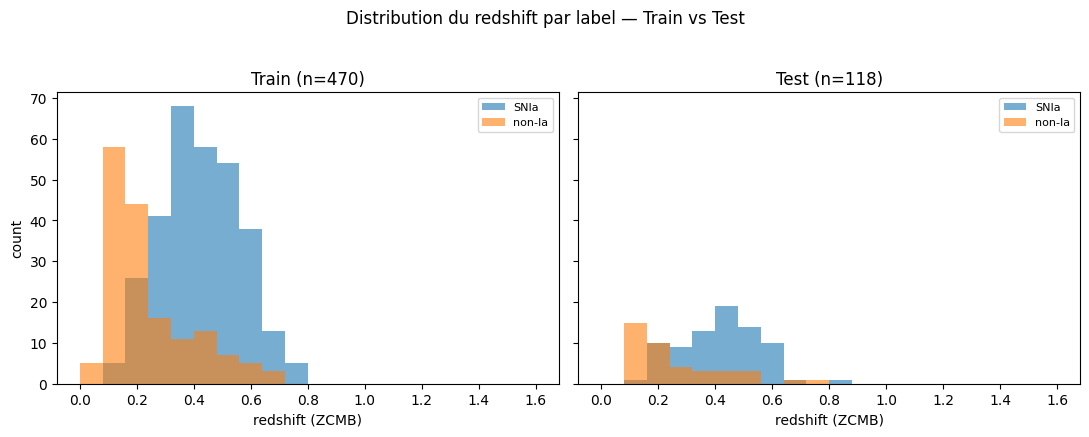

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, tight_layout=True)

for ax, (split_name, split_df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    for label_name, sub in split_df.groupby('label_name'):
        ax.hist(sub['redshift'], bins=20, range=(0, 1.6), alpha=0.6, label=label_name)
    ax.set_title(f"{split_name} (n={len(split_df)})")
    ax.set_xlabel("redshift (ZCMB)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("count")
fig.suptitle("Distribution du redshift par label — Train vs Test", y=1.03)
plt.show()

## 5 · Sélection des colonnes de features

On garde toutes les colonnes utiles à l'entraînement : les paramètres Bazin par bande
(`{band}_A, t0, t_fall, t_rise, B, t_max, f_max, m_p`), les couleurs (`c_*`), le redshift,
plus les identifiants et labels nécessaires au suivi (non utilisés comme features par le
classifieur, mais conservés pour traçabilité).

In [11]:
BANDS = ['u', 'g', 'r', 'i', 'z', 'Y']

feature_cols = []
for band in BANDS:
    feature_cols += [f'{band}_A', f'{band}_t0', f'{band}_t_fall', f'{band}_t_rise',
                      f'{band}_B', f'{band}_t_max', f'{band}_f_max', f'{band}_m_p']
feature_cols += [f'c_{BANDS[i]}{BANDS[i+1]}' for i in range(len(BANDS) - 1)]
feature_cols += ['redshift']

# Ne garder que les colonnes effectivement présentes (robustesse)
feature_cols = [c for c in feature_cols if c in df_labeled.columns]

id_cols = ['SNID', 'obj_class', 'label', 'label_name', 'is_good_fit', 'z_bin']
id_cols = [c for c in id_cols if c in df_labeled.columns]

keep_cols = id_cols + feature_cols
print(f"{len(feature_cols)} colonnes de features, {len(id_cols)} colonnes d'identification/label.")
print("\nFeatures :")
print(feature_cols)

54 colonnes de features, 5 colonnes d'identification/label.

Features :
['u_A', 'u_t0', 'u_t_fall', 'u_t_rise', 'u_B', 'u_t_max', 'u_f_max', 'u_m_p', 'g_A', 'g_t0', 'g_t_fall', 'g_t_rise', 'g_B', 'g_t_max', 'g_f_max', 'g_m_p', 'r_A', 'r_t0', 'r_t_fall', 'r_t_rise', 'r_B', 'r_t_max', 'r_f_max', 'r_m_p', 'i_A', 'i_t0', 'i_t_fall', 'i_t_rise', 'i_B', 'i_t_max', 'i_f_max', 'i_m_p', 'z_A', 'z_t0', 'z_t_fall', 'z_t_rise', 'z_B', 'z_t_max', 'z_f_max', 'z_m_p', 'Y_A', 'Y_t0', 'Y_t_fall', 'Y_t_rise', 'Y_B', 'Y_t_max', 'Y_f_max', 'Y_m_p', 'c_ug', 'c_gr', 'c_ri', 'c_iz', 'c_zY', 'redshift']


## 6 · Sauvegarde des échantillons train/test

In [12]:
train_out = train_df[keep_cols].reset_index(drop=True)
test_out  = test_df[keep_cols].reset_index(drop=True)

for name, d in (('train', train_out), ('test', test_out)):
    d.attrs['target_mode'] = TARGET_MODE
    d.attrs['require_good_fit'] = REQUIRE_GOOD_FIT
    d.attrs['test_size'] = TEST_SIZE
    d.attrs['random_seed'] = RANDOM_SEED
    d.attrs['n_z_bins_used'] = n_bins_used
    d.attrs['created_utc'] = datetime.now(timezone.utc).isoformat()

train_path = OUTPUT_DIR / "train_set.parquet"
test_path  = OUTPUT_DIR / "test_set.parquet"

train_out.to_parquet(train_path, index=False)
test_out.to_parquet(test_path, index=False)

print(f"Train écrit : {train_path}  ({train_out.shape})")
print(f"Test  écrit : {test_path}  ({test_out.shape})")

Train écrit : /Users/dagoret/Desktop/transcientslightcurves/notebooks/03_fitbazinfunc/train_test_sets/train_set.parquet  ((470, 59))
Test  écrit : /Users/dagoret/Desktop/transcientslightcurves/notebooks/03_fitbazinfunc/train_test_sets/test_set.parquet  ((118, 59))


## 7 · Vérification rapide : relecture

Aperçu des fichiers sauvegardés, prêts à être relus dans le notebook d'entraînement
du classifieur (ex. Random Forest sur `feature_cols`, cible `label`).

In [13]:
train_check = pd.read_parquet(train_path)
test_check  = pd.read_parquet(test_path)

print(f"train_set.parquet : shape={train_check.shape}")
display(train_check.head())

print(f"\ntest_set.parquet : shape={test_check.shape}")
display(test_check.head())

train_set.parquet : shape=(470, 59)


,SNID,obj_class,label,label_name,is_good_fit,u_A,u_t0,u_t_fall,u_t_rise,u_B,...,Y_B,Y_t_max,Y_f_max,Y_m_p,c_ug,c_gr,c_ri,c_iz,c_zY,redshift
0,42621049,SNIa-SALT3,1,SNIa,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.490504
1,2717014,SNIa-SALT3,1,SNIa,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.123878,NaN,NaN,0.366458
2,13716470,SNIa-SALT3,1,SNIa,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.205562,NaN,NaN,0.444493
3,55797185,SNIb-Templates,0,non-Ia,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.034072,0.220621,NaN,0.133593
4,36814103,SNIb-Templates,0,non-Ia,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.220878,NaN,NaN,0.122844



test_set.parquet : shape=(118, 59)


,SNID,obj_class,label,label_name,is_good_fit,u_A,u_t0,u_t_fall,u_t_rise,u_B,...,Y_B,Y_t_max,Y_f_max,Y_m_p,c_ug,c_gr,c_ri,c_iz,c_zY,redshift
0,43559856,SNIa-SALT3,1,SNIa,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.015884,NaN,NaN,0.459547
1,72832789,SNII-Templates,0,non-Ia,True,0.0,0.0,0.0,0.0,50.324425,...,NaN,NaN,NaN,NaN,NaN,NaN,0.048961,-0.198705,NaN,0.139163
2,65475939,SNIa-SALT3,1,SNIa,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.511168
3,47895708,SNIa-SALT3,1,SNIa,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.456694
4,38553498,SNII-Templates,0,non-Ia,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.019698,NaN,0.226880
